In [1]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [2]:
import numpy as np

In [24]:
train_dir  = "flowers"

In [25]:
img_width, img_height = 200,200

In [26]:
train_datagen=ImageDataGenerator(
    rescale=1.0/225,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

In [27]:
train_generator=train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width,img_height),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 3440 images belonging to 5 classes.


In [28]:
model_hoa = Sequential([
    Conv2D(32,(3,3), activation='relu', input_shape=(200,200,3)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation= 'softmax')
])

In [29]:
model_hoa.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])
model_hoa.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 73728)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     9,437,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,531,205 (36.36 MB)

 Trainable params: 9,531,205 (36.36 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
history=model_hoa.fit(train_generator,epochs=100)

Epoch 1/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 24s 221ms/step - accuracy: 0.5738 - loss: 1.0565
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 27s 245ms/step - accuracy: 0.6058 - loss: 0.9977
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 29s 268ms/step - accuracy: 0.6238 - loss: 0.9699
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 30s 276ms/step - accuracy: 0.6352 - loss: 0.9227
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 31s 284ms/step - accuracy: 0.6535 - loss: 0.8961
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 31s 287ms/step - accuracy: 0.6561 - loss: 0.8702
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 33s 300ms/step - accuracy: 0.6654 - loss: 0.8719
Epoch 8/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 35s 320ms/step - accuracy: 0.6747 - loss: 0.8402
Epoch 9/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 39s 363ms/step - accuracy: 0.6849 - loss: 0.8263
Epoch 10/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 35s 321ms/step - accuracy: 0.6840 - loss: 0.8228
Epoch 11/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 34s 311ms/step - accuracy: 0.6977 - loss: 0.8032
Epoch 12

In [33]:
model_hoa.save("flowers_detect.h5")

In [34]:
from keras.models import load_model
model = load_model("flowers_detect.h5")

In [35]:
import cv2

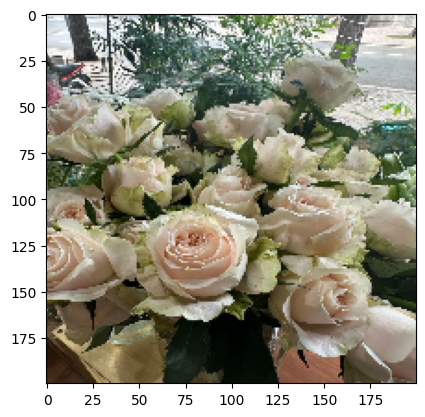

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Người tiên đoán: rose
Độ tự tin: 50.13%


In [ ]:
img = cv2.imread("707347245_914269714997799_1970630511356696634_n.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (200, 200))
plt.imshow(img_resized)
plt.show()
img_array = img_resized / 255.0
img_array = img_array.reshape(1, 200, 200, 3)
pred = model.predict(img_array)
prediction = np.argmax(pred)
confidence = np.max(pred)
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Hoa tiên đoán: {person_name}")
print(f"Độ tự tin: {confidence * 100:.2f}%")

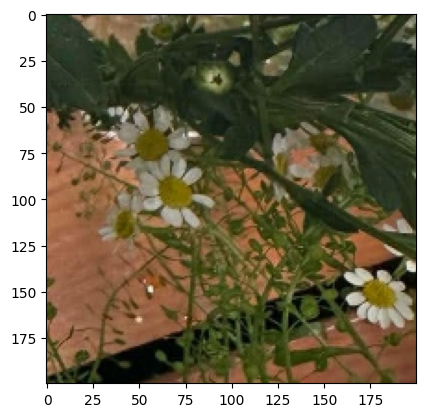

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Hoa tiên đoán: daisy
Độ tự tin: 99.42%


In [38]:
img = cv2.imread("707780855_982368567708366_2945818702743639664_n.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (200, 200))
plt.imshow(img_resized)
plt.show()
img_array = img_resized / 255.0
img_array = img_array.reshape(1, 200, 200, 3)
pred = model.predict(img_array)
prediction = np.argmax(pred)
confidence = np.max(pred)
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Hoa tiên đoán: {person_name}")
print(f"Độ tự tin: {confidence * 100:.2f}%")

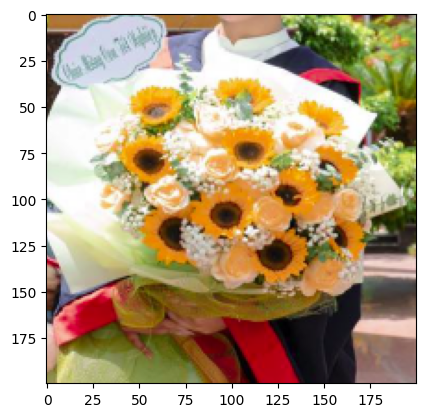

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Hoa tiên đoán: sunflower
Độ tự tin: 99.09%


In [39]:
img = cv2.imread("C:\Salem\AI\AI_flowers\Screenshot 2026-05-29 155523.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (200, 200))
plt.imshow(img_resized)
plt.show()
img_array = img_resized / 255.0
img_array = img_array.reshape(1, 200, 200, 3)
pred = model.predict(img_array)
prediction = np.argmax(pred)
confidence = np.max(pred)
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Hoa tiên đoán: {person_name}")
print(f"Độ tự tin: {confidence * 100:.2f}%")

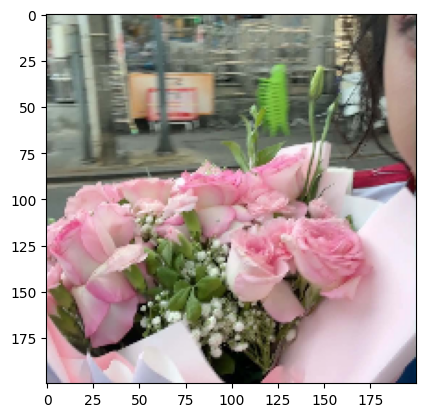

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Hoa tiên đoán: rose
Độ tự tin: 84.47%


In [40]:
img = cv2.imread("fa881572-b35e-45a2-80b8-531a4fd009b9.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (200, 200))
plt.imshow(img_resized)
plt.show()
img_array = img_resized / 255.0
img_array = img_array.reshape(1, 200, 200, 3)
pred = model.predict(img_array)
prediction = np.argmax(pred)
confidence = np.max(pred)
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Hoa tiên đoán: {person_name}")
print(f"Độ tự tin: {confidence * 100:.2f}%")